# Do tie piles in prevalence judgments blow up the Beta-mixture fits?

**Theory:** the fitted beta params explode because many participants give the *same* prevalence
judgment (e.g. exactly 50), and a Beta component can collapse into a near-delta spike on that
pile. Under a continuous *density* likelihood this is an unbounded-likelihood degeneracy:
the density at the tied value grows without limit as $\alpha+\beta \to \infty$, so MLE chases it forever.

Four tests:
1. **Real data, correlational** — does the size of a feature's largest interior tie pile predict
   how far the fitted $\alpha+\beta$ runs?
2. **Synthetic, causal** — smooth mixture data with *injected* ties at 0.5; sweep the tie count.
   Also: is 1/100 quantization alone (no manual injection) enough?
3. **Ablation** — break ties on the worst real features with sub-bin jitter (preserves the
   distribution at bin resolution, removes exact ties). Explosion should vanish.
4. **Mixture weight as amplifier** — sweep pz1; extreme weights free the minority component to
   spike, but the degeneracy should appear regardless. Compared against the bounded *interval*
   likelihood now in `model_jax.py`.

All density fits here are float64, so explosions reflect the statistical degeneracy itself —
not the float32 cancellation that produced the absurd +8.6e17 log-likelihoods in the VBMC
diagnostic (that was a separate, numerical amplifier on top of this).

In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import beta as sp_beta
from scipy.stats import spearmanr
from scipy.optimize import minimize

CSV_TO_FEATURE = {
    'diet_can_eat_spicy_1':  'can eat spicy food',
    'diet_breakfast_late_1': 'eat breakfast very late',
    'diet_five_meals_day_1': 'eat five meals a day',
    'diet_like_juice_pulp_1':'like juice with pulp',
    'diet_pepper_on_all_1':  'put pepper on all their foods',
    'pers_cry_easily_1':     'cry easily',
    'pers_collect_rocks_1':  'like to collect rocks',
    'pers_like_to_dance_1':  'like to dance',
    'pers_like_highfive_1':  'like to give high-fives',
    'pers_read_books_1':     'like to read books',
    'phys_can_roll_tongue_1':'can roll their tongue',
    'phys_can_snap_toes_1':  'can snap with their toes',
    'phys_can_wiggle_ears_1':'can wiggle their ears',
    'phys_cold_hands_feet_1':'have cold hands and feet',
    'phys_snore_sleep_1':    'snore when they sleep',
}

with open('../../data/study9.csv') as f:
    rows = list(csv.reader(f))
header = rows[0]
cols = [header.index(c) for c in CSV_TO_FEATURE]
feature_names = list(CSV_TO_FEATURE.values())
ratings = []
for row in rows[3:]:
    try:
        ratings.append([int(row[i]) / 100.0 for i in cols])
    except (ValueError, IndexError):
        pass
R = np.array(ratings)   # (N, J)
N, J = R.shape
print(f"{N} participants x {J} features")

402 participants x 15 features


## The old objective: density likelihood, in float64

This is the pre-fix objective from `model_jax.py` (Beta-mixture *density*, responses clipped to
[0.01, 0.99]), reimplemented in float64 numpy/scipy. Any explosion here is the statistical
degeneracy itself. `spike_info` reports the concentration ($\alpha+\beta$) and mean of the most
concentrated component — for a spike, the mean tells us *where* it collapsed.

In [2]:
LOG_LIMIT = 30.0          # exp(30) ~ 1e13; "explosion" = running orders past data scale
SPIKE_THRESHOLD = 1e4     # alpha+beta above this = near-delta component (sd < 0.005)
LOG_INITS = np.log(np.array([   # same starting points as model_jax
    [5., 1., 1., 5.],
    [3., 1., 1., 3.],
    [8., 2., 2., 5.],
    [2., 2., 2., 2.],
]))

def density_nll(log_params, r, th):
    a1, b1, a2, b2 = np.exp(np.clip(log_params, -LOG_LIMIT, LOG_LIMIT))
    lp1 = sp_beta.logpdf(r, a1, b1)
    lp2 = sp_beta.logpdf(r, a2, b2)
    return -np.sum(np.logaddexp(np.log(th) + lp1, np.log1p(-th) + lp2))

def fit_density(r, th):
    """Best-of-inits density-likelihood fit; th is a scalar mixture weight.
    Returns (params (4,) = a1,b1,a2,b2, nll). Component 1 carries weight th."""
    r = np.clip(r, 0.01, 0.99)          # the old pipeline's clip
    th_vec = np.full(r.shape, th)
    best_x, best_f = None, np.inf
    for x0 in LOG_INITS:
        res = minimize(density_nll, x0, args=(r, th_vec), method='L-BFGS-B',
                       bounds=[(-LOG_LIMIT, LOG_LIMIT)] * 4)
        if res.fun < best_f:
            best_f, best_x = res.fun, res.x
    return np.exp(best_x), best_f

def spike_info(params):
    """(max alpha+beta over the two components, mean of the more concentrated one)"""
    a1, b1, a2, b2 = params
    c1, c2 = a1 + b1, a2 + b2
    return (c1, a1 / c1) if c1 >= c2 else (c2, a2 / c2)

## Tie-pile statistics per feature

The theory cares about *interior* piles (values strictly between 0 and 100): piles at the
endpoints are absorbed by J-shaped components ($\alpha$ or $\beta < 1$ already puts diverging
density at the edges, which is cheaper than a spike).

In [12]:
max_interior_tie = np.zeros(J, dtype=int)
interior_tie_val = np.zeros(J)
# n_judgments = np.zeros(J, dtype=int) 

print(f"{'feature':<32} {'biggest interior pile':>22} {'n@0':>5} {'n@100':>6}") #{'n_judgments':>12}
for j in range(J):
    c = Counter((R[:, j] * 100).round().astype(int))
    interior = {v: n for v, n in c.items() if 0 < v < 100}
    v_best, n_best = max(interior.items(), key=lambda kv: kv[1])
    max_interior_tie[j] = n_best
    interior_tie_val[j] = v_best / 100
    # n_judgments[j] = len(R[:, j])  # or np.sum(~np.isnan(R[:, j])) if NaN values exist
    print(f"{feature_names[j]:<32} {f'{n_best} @ {v_best}':>22} {c.get(0,0):>5} {c.get(100,0):>6}") #{int(n_judgments[j]):>12}

feature                           biggest interior pile   n@0  n@100
can eat spicy food                              48 @ 50     4     47
eat breakfast very late                         39 @ 25     2     26
eat five meals a day                            30 @ 50     3     42
like juice with pulp                            70 @ 50     4     42
put pepper on all their foods                   40 @ 50     3     34
cry easily                                      51 @ 50     2     28
like to collect rocks                           35 @ 50     3     39
like to dance                                   36 @ 50     1     64
like to give high-fives                         41 @ 50     3     62
like to read books                              41 @ 50     2     54
can roll their tongue                           36 @ 50     2     44
can snap with their toes                        31 @ 50     6     48
can wiggle their ears                           24 @ 25     1     52
have cold hands and feet          

## Experiment 1 — real data: do tie piles predict spikes?

Density-fit every feature at several mixture weights; record the worst (largest) $\alpha+\beta$.
If the theory is right: (a) concentration should correlate with pile size, and (b) the spike
component's *mean* should land exactly on the pile's value.

Spearman(interior pile size, log max alpha+beta): rho=0.33, p=0.2225

feature                           pile    max a+b  spike mean  pile value
can eat spicy food                  48   2.14e+13       0.500        0.50
like to dance                       36   2.14e+13       0.500        0.50
can roll their tongue               36   2.14e+13       0.500        0.50
like juice with pulp                70   2.14e+13       0.500        0.50
snore when they sleep               52   2.14e+13       0.500        0.50
have cold hands and feet            39   2.14e+13       0.500        0.50
like to read books                  41   2.14e+13       0.500        0.50
like to give high-fives             41   2.87e+07       0.500        0.50
eat breakfast very late             39   3.66e+06       0.250        0.25
like to collect rocks               35        194           -        0.50
can snap with their toes            31       53.9           -        0.50
eat five meals a day                30    

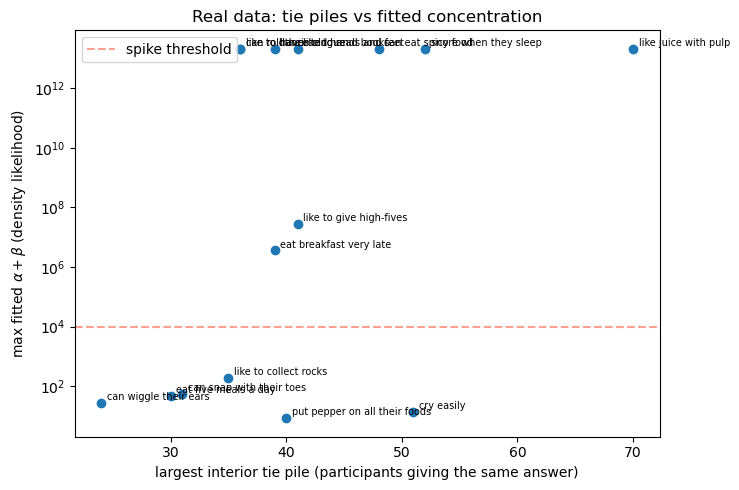

In [4]:
TH_GRID = [0.3, 0.5, 0.7, 0.85, 0.95]

max_conc = np.zeros(J)
spike_means = [np.nan] * J
for j in range(J):
    for th in TH_GRID:
        params, _ = fit_density(R[:, j], th)
        conc, mean = spike_info(params)
        if conc > max_conc[j]:
            max_conc[j] = conc
            spike_means[j] = mean

rho, p = spearmanr(max_interior_tie, np.log(max_conc))
print(f"Spearman(interior pile size, log max alpha+beta): rho={rho:.2f}, p={p:.4f}\n")
print(f"{'feature':<32} {'pile':>5} {'max a+b':>10} {'spike mean':>11} {'pile value':>11}")
for j in np.argsort(-max_conc):
    spk = f"{spike_means[j]:.3f}" if max_conc[j] > SPIKE_THRESHOLD else "-"
    print(f"{feature_names[j]:<32} {max_interior_tie[j]:>5} {max_conc[j]:>10.3g} "
          f"{spk:>11} {interior_tie_val[j]:>11.2f}")

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(max_interior_tie, max_conc, zorder=3)
for j in range(J):
    ax.annotate(feature_names[j], (max_interior_tie[j], max_conc[j]), fontsize=7,
                xytext=(4, 2), textcoords='offset points')
ax.set_yscale('log')
ax.axhline(SPIKE_THRESHOLD, ls='--', color='tomato', alpha=0.6, label='spike threshold')
ax.set_xlabel('largest interior tie pile (participants giving the same answer)')
ax.set_ylabel(r'max fitted $\alpha+\beta$ (density likelihood)')
ax.set_title('Real data: tie piles vs fitted concentration')
ax.legend()
plt.tight_layout(); plt.show()

## Experiment 2 — synthetic data: ties *cause* the explosion

Draw smooth (continuous, tie-free) data from a known Beta mixture, then inject m exact ties at
0.50 and refit. A second condition first quantizes the smooth draws to the 1/100 response grid
(like real sliders) before injecting — testing whether realistic quantization alone already
creates enough natural piling to trigger spikes.

Note the density likelihood is *technically* unbounded for any m ≥ 1 (a spike on a single point
already diverges) — the question is when the degenerate basin becomes wide enough that a generic
multi-start optimizer actually falls in.

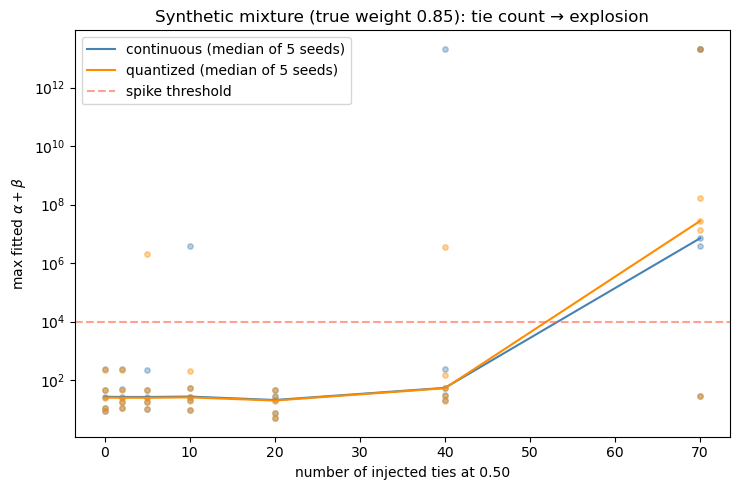

   m  continuous median a+b  quantized median a+b
   0                   27.1                  25.4
   2                   26.7                  25.1
   5                   26.6                    25
  10                   27.5                  25.8
  20                     21                  20.1
  40                   54.6                    53
  70               7.16e+06              2.79e+07


In [5]:
TH_TRUE = 0.85
KL, NKL = (2.0, 0.7), (1.5, 4.0)      # right-skewed kl, left-leaning nkl
M_GRID = [0, 2, 5, 10, 20, 40, 70]
N_SEEDS = 5

def synth(seed):
    rng = np.random.default_rng(seed)
    z = rng.random(N) < TH_TRUE
    r = np.where(z, rng.beta(*KL, N), rng.beta(*NKL, N))
    return rng, r

results = {(c, m): [] for c in ('continuous', 'quantized') for m in M_GRID}
for seed in range(N_SEEDS):
    for m in M_GRID:
        rng, r = synth(seed)
        idx = rng.choice(N, m, replace=False)
        for cond in ('continuous', 'quantized'):
            r_c = np.round(r * 100) / 100 if cond == 'quantized' else r.copy()
            r_c[idx] = 0.50
            params, _ = fit_density(r_c, TH_TRUE)
            results[(cond, m)].append(spike_info(params)[0])

fig, ax = plt.subplots(figsize=(7.5, 5))
for cond, color in [('continuous', 'steelblue'), ('quantized', 'darkorange')]:
    for m in M_GRID:
        ax.scatter([m] * N_SEEDS, results[(cond, m)], color=color, alpha=0.4, s=15)
    ax.plot(M_GRID, [np.median(results[(cond, m)]) for m in M_GRID],
            color=color, label=f'{cond} (median of {N_SEEDS} seeds)')
ax.set_yscale('log')
ax.axhline(SPIKE_THRESHOLD, ls='--', color='tomato', alpha=0.6, label='spike threshold')
ax.set_xlabel('number of injected ties at 0.50')
ax.set_ylabel(r'max fitted $\alpha+\beta$')
ax.set_title(f'Synthetic mixture (true weight {TH_TRUE}): tie count → explosion')
ax.legend()
plt.tight_layout(); plt.show()

print(f"{'m':>4} {'continuous median a+b':>22} {'quantized median a+b':>21}")
for m in M_GRID:
    print(f"{m:>4} {np.median(results[('continuous', m)]):>22.3g} "
          f"{np.median(results[('quantized', m)]):>21.3g}")

## Experiment 3 — ablation: break the ties, keep everything else

Add sub-bin uniform jitter (±0.004, less than half a response bin) to the worst real features.
The distribution is unchanged at bin resolution; only the *exact* ties are destroyed. If ties
are the cause, the explosion should disappear.

In [6]:
worst = np.argsort(-max_conc)[:4]
print(f"{'feature':<32} {'raw max a+b':>12} {'jittered max a+b':>17}")
for j in worst:
    concs_raw, concs_jit = [], []
    rng = np.random.default_rng(int(j))
    r_jit = R[:, j] + rng.uniform(-0.004, 0.004, N)
    for th in TH_GRID:
        params, _ = fit_density(R[:, j], th)
        concs_raw.append(spike_info(params)[0])
        params, _ = fit_density(r_jit, th)
        concs_jit.append(spike_info(params)[0])
    print(f"{feature_names[j]:<32} {max(concs_raw):>12.3g} {max(concs_jit):>17.3g}")

feature                           raw max a+b  jittered max a+b
can eat spicy food                   2.14e+13          4.46e+04
like to dance                        2.14e+13          2.67e+06
can roll their tongue                2.14e+13          3.04e+06
like juice with pulp                 2.14e+13          9.24e+06


## Experiment 4 — mixture weight is an amplifier, not the cause

Sweep the mixture weight pz1 on the worst feature. Predictions: the density fit spikes across a
wide range of weights (the degeneracy doesn't need an extreme weight), but extreme weights make
the near-weightless component freest to collapse. The interval likelihood (current `model_jax`)
stays at or below its saturation cap at every weight.

feature: can eat spicy food  (pile: 48 @ 0.50)


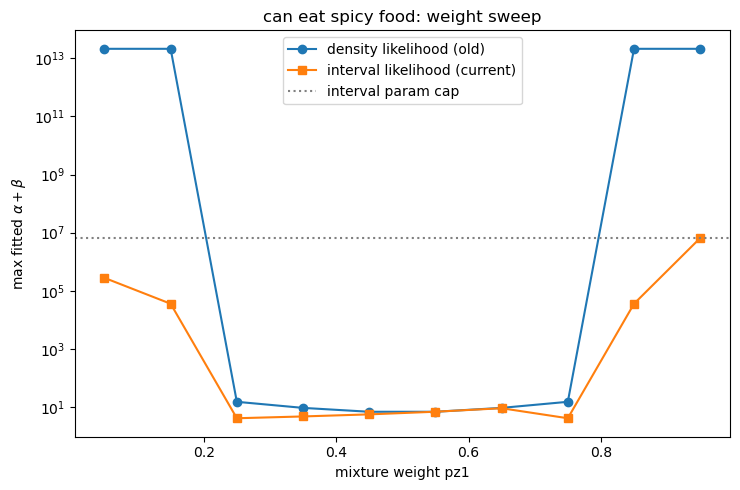

mixture weight carried by the spiking component, per th:
  pz1=0.05: spike component weight=0.05  a+b=2.14e+13
  pz1=0.15: spike component weight=0.15  a+b=2.14e+13
  pz1=0.25: spike component weight=0.25  a+b=14.9
  pz1=0.35: spike component weight=0.35  a+b=9.23
  pz1=0.45: spike component weight=0.45  a+b=6.79
  pz1=0.55: spike component weight=0.45  a+b=6.79
  pz1=0.65: spike component weight=0.35  a+b=9.23
  pz1=0.75: spike component weight=0.25  a+b=14.9
  pz1=0.85: spike component weight=0.15  a+b=2.14e+13
  pz1=0.95: spike component weight=0.05  a+b=2.14e+13


In [7]:
import os
os.environ['JAX_PLATFORMS'] = 'cpu'
import jax.numpy as jnp
from model_jax import _fit_one_feature, _LOG_PARAM_LIMIT

j = int(np.argsort(-max_conc)[0])
print(f"feature: {feature_names[j]}  "
      f"(pile: {max_interior_tie[j]} @ {interior_tie_val[j]:.2f})")
TH_SWEEP = np.linspace(0.05, 0.95, 10)

conc_density, conc_interval, spike_weight = [], [], []
for th in TH_SWEEP:
    params, _ = fit_density(R[:, j], th)
    a1, b1, a2, b2 = params
    conc_density.append(spike_info(params)[0])
    spike_weight.append(th if (a1 + b1) >= (a2 + b2) else 1 - th)
    lp = np.exp(np.array(_fit_one_feature(jnp.array(R[:, j]), jnp.full(N, th))))
    conc_interval.append(max(lp[0] + lp[1], lp[2] + lp[3]))

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(TH_SWEEP, conc_density, 'o-', label='density likelihood (old)')
ax.plot(TH_SWEEP, conc_interval, 's-', label='interval likelihood (current)')
ax.axhline(2 * np.exp(_LOG_PARAM_LIMIT), ls=':', color='gray', label='interval param cap')
ax.set_yscale('log')
ax.set_xlabel('mixture weight pz1')
ax.set_ylabel(r'max fitted $\alpha+\beta$')
ax.set_title(f'{feature_names[j]}: weight sweep')
ax.legend()
plt.tight_layout(); plt.show()

print("mixture weight carried by the spiking component, per th:")
for th, w, c in zip(TH_SWEEP, spike_weight, conc_density):
    print(f"  pz1={th:.2f}: spike component weight={w:.2f}  a+b={c:.3g}")

## Conclusions

*(to be filled in after running)*